In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import math as m
import pyspark.sql.functions as F

# Create a spark session (which will run spark jobs)
spark = (
    SparkSession.builder.appName("MAST30034 Tutorial 1")
    .config("spark.sql.repl.eagerEval.enabled", True) 
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .config("spark.driver.memory", "6g")
    .getOrCreate()
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/08/27 19:28:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
# Outlier detection and treatment using IQR altered from https://www.machinelearningplus.com/pyspark/pyspark-outlier-detection-and-treatment/ to handle large datasets
def iqr_outlier_treatment(dataframe, columns, n):
    """
    Detects and treats outliers using IQR for multiple variables in a PySpark DataFrame.
    :param dataframe: The input PySpark DataFrame
    :param columns: A list of columns to apply IQR outlier treatment
    :param factor: The IQR factor to use for detecting outliers (default is 1.5)
    :return: The processed DataFrame with outliers treated
    """
    factor = m.sqrt(np.log(n)) - 0.5  # Adjust the factor based on the number of standard deviations
    for column in columns:
        # Calculate Q1, Q3, and IQR
        quantiles = dataframe.approxQuantile(column, [0.25, 0.75], 0.01)
        q1, q3 = quantiles[0], quantiles[1]
        iqr = q3 - q1
        # Define the upper and lower bounds for outliers
        lower_bound = q1 - factor * iqr
        upper_bound = q3 + factor * iqr
        # Filter outliers and update the DataFrame
        dataframe = dataframe.filter((F.col(column) >= lower_bound) & (F.col(column) <= upper_bound))
    return dataframe

**Creating the Training(Analysis) Data**

In [3]:
sdf_2024_green = spark.read.parquet("../taxi_data/green/2024")

sdf_2024_green = sdf_2024_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

sdf_2024_yellow = spark.read.parquet("../taxi_data/yellow/2024")

sdf_2024_yellow = sdf_2024_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

In [4]:
sdf_2023_green = spark.read.parquet("../taxi_data/green/2023")

sdf_2023_green = sdf_2023_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

sdf_2023_yellow = spark.read.parquet("../taxi_data/yellow/2023")

sdf_2023_yellow = sdf_2023_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")


In [5]:
sdf_2024 = sdf_2024_green.unionByName(sdf_2024_yellow, allowMissingColumns=True)
sdf_2024.count()

41829938

In [6]:
sdf_2023 = sdf_2023_green.unionByName(sdf_2023_yellow, allowMissingColumns=True)
sdf_2023.count()

15610024

In [7]:
# Read the irregular data for 2023 and 2024 in the month of October and removed all the rows with null pickup and dropoff datetimes
temp = spark.read.parquet("../taxi_data/irregular")

temp = temp.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee")

temp_work = temp.filter(F.col("pickup_datetime").isNotNull() & F.col("dropoff_datetime").isNotNull()) \
    .filter(F.col("pickup_datetime") < F.col("dropoff_datetime"))

sdf_2023 = sdf_2023.unionByName(temp_work, allowMissingColumns=True)

sdf_2023.count()

15676112

In [8]:
sdf_train = sdf_2023.unionByName(sdf_2024, allowMissingColumns=True)
sdf_train.count()

57506050

In [9]:
sdf_train.show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+
|       1|2023-09-01 00:08:04|2023-09-01 00:13:39|          41|          75|          1.1|        7.9|       0.0|        10.4|                 0.0|
|       1|2023-09-01 00:30:44|2023-09-01 00:39:30|          74|         236|          1.8|       10.7|      3.15|        19.1|                2.75|
|       2|2023-09-01 00:14:39|2023-09-01 00:38:30|          93|         205|        10.52|       60.0|       0.0|        61.0|                 0.0|
|       2|2023-09-01 00:35:48|2023-09-01 00:56:48|         112|          17|         4.72|       23.3|      10.0

**Creating Test Data**

In [10]:
sdf_2025_green = spark.read.parquet("../taxi_data/green/2025")

sdf_2025_green = sdf_2025_green.withColumnRenamed("lpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("lpep_dropoff_datetime", "dropoff_datetime")\
    .drop("store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee", "cbd_congestion_fee")

sdf_2025_yellow = spark.read.parquet("../taxi_data/yellow/2025")

sdf_2025_yellow = sdf_2025_yellow.withColumnRenamed("tpep_pickup_datetime", "pickup_datetime") \
    .withColumnRenamed("tpep_dropoff_datetime", "dropoff_datetime")\
    .drop("Airport_Fee", "store_and_fwd_flag", "RateCodeID", "passenger_count", "payment_type", "mta_tax", "tolls_amount", "improvement_surcharge", "extra", "trip_type", "ehail_fee", "cbd_congestion_fee")

In [11]:
sdf_2025 = sdf_2025_green.unionByName(sdf_2025_yellow, allowMissingColumns=True)
sdf_2025.count()

24386791

**Preprocessing for Train Data**

In [12]:
# Calculate travel time in seconds
sdf_train = sdf_train.withColumn("travel_time_seconds",\
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")))
# filtering the data for valid trips
# travel time should be greater than  or equal to 3 minutes (180 seconds) and less than or equal to 5 hours (18000 seconds) 
# trip distance should be greater than 1 mile as it is reasonable to assume that a taxi ride should cover some distance more than a mile to be stuck in traffic and be worth it
# fare amount should be greater than 3 dollars and total amount should be greater than 3 dollars as according to the NYC Taxi and Limousine Commission,\
#  the initial fare for a taxi ride is $3.00
sdf_train_filtered = sdf_train.filter((F.col("travel_time_seconds") >= 180) & (F.col("trip_distance") > 1) & (F.col("fare_amount") > 3) & (F.col("total_amount") > 3) \
    & (F.col("travel_time_seconds") <= 18000))

# congestion surcharge should be greater than or equal to 0 and not null as according to https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
sdf_train_filtered = sdf_train_filtered.withColumn("congestion_surcharge",\
    F.when((F.col("congestion_surcharge").isNotNull()) & ~(F.isnan("congestion_surcharge")), F.col("congestion_surcharge")).otherwise(0))

# Checking NaN or null values in the dataframe
# adapted from https://sparkbyexamples.com/pyspark/pyspark-find-count-of-null-none-nan-values/
from pyspark.sql.functions import col,isnan, when, count
sdf_train_filtered.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in sdf_train_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

# removing outlier trips based on travel time and trip distance
sdf_train_filtered_outlier = iqr_outlier_treatment(sdf_train_filtered, ["travel_time_seconds", "trip_distance"], n = sdf_train_filtered.count())

# adding a date column for each trip
split_col1 = F.split(sdf_train_filtered_outlier['pickup_datetime'], ' ')
sdf_train_filtered_outlier = sdf_train_filtered_outlier.withColumn('date', split_col1.getItem(0))

sdf_train_filtered_outlier.orderBy("trip_distance", ascending=False).show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|      date|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+
|       2|2023-08-11 17:11:50|2023-08-11 18:01:18|          43|         130|        14.52|       63.9|       0.0|       74.45|                 0.0|               2968|2023-08-11|
|       2|2024-01-05 19:44:48|2024-01-05 20:17:57|         132|          64|        14.52|       56.2|       0.0|       61.95|                 0.0|               1989|2024-01-05|
|       2|2024-02-05 19:24:32|2024-02-05 19:52:13|         138|         141|        14.52|       56.2|   

In [13]:
sdf_train_filtered_outlier.count()

39642599

In [14]:
# average new york taxi speed according to https://medium.com/@jiaminhan/looking-through-the-taxi-meter-analysis-of-the-nyc-green-taxi-data-c1dbe5619afe
average_speed = 14 / 3600 # in miles per second

# average time spent in traffic  per day in new york according to https://congestionreliefzone.mta.info/about
average_time_in_traffic = m.floor((117/365) * 3600) # in seconds

# tolerance time for congestion time
tolerance = 120

sdf_train_filtered_outlier = sdf_train_filtered_outlier.withColumn("congestion_time_seconds",\
    F.when((F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed) > tolerance),\
    (F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed))).otherwise(0))

In [15]:
sdf_train_filtered_outlier.orderBy("congestion_time_seconds", ascending=False).show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+-----------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|      date|congestion_time_seconds|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+-----------------------+
|       2|2024-08-22 01:19:21|2024-08-22 02:33:10|         170|         230|         1.06|        6.5|       0.0|        11.5|                 2.5|               4429|2024-08-22|      4156.428571428572|
|       2|2023-09-08 18:49:29|2023-09-08 20:03:15|          82|         158|         1.05|       63.9|     15.47|       92.81|                 2.5|               4426|2023-09-08|          

In [16]:
# filtering out rows where congestion time is less than 0 to find trips that were in congestion
final_filtered_df = sdf_train_filtered_outlier.filter(F.col("congestion_time_seconds") > 0)
final_filtered_df.count()

26021194

**Preprocessing for Test Data**

In [17]:
# Calculate travel time in seconds
sdf_2025 = sdf_2025.withColumn("travel_time_seconds",\
    (F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime")))
# filtering the data for valid trips
# travel time should be greater than  or equal to 3 minutes (180 seconds) and less than or equal to 5 hours (18000 seconds) 
# trip distance should be greater than 1 mile as it is reasonable to assume that a taxi ride should cover some distance more than a mile to be stuck in traffic and be worth it
# fare amount should be greater than 3 dollars and total amount should be greater than 3 dollars as according to the NYC Taxi and Limousine Commission,\
#  the initial fare for a taxi ride is $3.00
sdf_2025_filtered = sdf_2025.filter((F.col("travel_time_seconds") >= 180) & (F.col("trip_distance") > 1) & (F.col("fare_amount") > 3) & (F.col("total_amount") > 3) \
    & (F.col("travel_time_seconds") <= 18000))

# congestion surcharge should be greater than or equal to 0 and not null as according to https://www.nyc.gov/site/tlc/about/congestion-surcharge.page
sdf_2025_filtered = sdf_2025_filtered.withColumn("congestion_surcharge",\
    F.when((F.col("congestion_surcharge").isNotNull()) & ~(F.isnan("congestion_surcharge")), F.col("congestion_surcharge")).otherwise(0))

# Checking NaN or null values in the dataframe
# adapted from https://sparkbyexamples.com/pyspark/pyspark-find-count-of-null-none-nan-values/
sdf_2025_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_2025_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

# removing outlier trips based on travel time and trip distance
sdf_2025_filtered_outlier = iqr_outlier_treatment(sdf_2025_filtered, ["travel_time_seconds", "trip_distance"], n = sdf_2025_filtered.count())

# adding a date column for each trip
split_col2 = F.split(sdf_2025_filtered_outlier['pickup_datetime'], ' ')
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.withColumn('date', split_col2.getItem(0))

sdf_2025_filtered_outlier.orderBy("trip_distance", ascending=False).show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|      date|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+
|       2|2025-06-19 09:57:35|2025-06-19 10:36:14|          92|         265|        14.15|       64.6|       0.0|        66.1|                 0.0|               2319|2025-06-19|
|       2|2025-02-24 15:37:41|2025-02-24 16:23:44|         132|           7|        14.15|       59.7|     13.09|       78.54|                 0.0|               2763|2025-02-24|
|       2|2025-06-24 18:24:42|2025-06-24 18:59:06|         138|         200|        14.15|       56.2|   

In [18]:
sdf_2025_filtered.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in sdf_2025_filtered.drop("pickup_datetime", "dropoff_datetime").columns])

VendorID,PULocationID,DOLocationID,trip_distance,fare_amount,tip_amount,total_amount,congestion_surcharge,travel_time_seconds
0,0,0,0,0,0,0,0,0


In [19]:
sdf_2025_filtered_outlier = sdf_2025_filtered_outlier.withColumn("congestion_time_seconds",\
    F.when((F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed) > tolerance),\
    (F.col("travel_time_seconds") - (F.col("trip_distance") / average_speed))).otherwise(0))

sdf_2025_filtered_outlier.show(10)

+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+-----------------------+
|VendorID|    pickup_datetime|   dropoff_datetime|PULocationID|DOLocationID|trip_distance|fare_amount|tip_amount|total_amount|congestion_surcharge|travel_time_seconds|      date|congestion_time_seconds|
+--------+-------------------+-------------------+------------+------------+-------------+-----------+----------+------------+--------------------+-------------------+----------+-----------------------+
|       2|2025-05-01 00:17:04|2025-05-01 00:56:06|          25|         216|         9.34|       44.3|       0.0|        46.8|                 0.0|               2342|2025-05-01|                    0.0|
|       2|2025-05-01 00:56:16|2025-05-01 01:10:26|         160|         129|         2.95|       16.3|       0.0|        18.8|                 0.0|                850|2025-05-01|          

In [20]:
final_filtered_testdf = sdf_2025_filtered_outlier.filter(F.col("congestion_time_seconds") > 0)
final_filtered_testdf.count()

10320207

**Data Analysis**

In [21]:
from pyspark.sql import functions as F
# Calculate median congestion time and total trips for each DOLocationID
# median used because of obvious skewness in the data (see histogram below)
congestion_groupby = final_filtered_df.groupBy("DOLocationID").agg(F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.count("DOLocationID").alias("total_trips"))

congestion_groupby.orderBy("median_congestion_time_seconds", ascending=False).show(10)


+------------+------------------------------+-----------+
|DOLocationID|median_congestion_time_seconds|total_trips|
+------------+------------------------------+-----------+
|         204|            2151.5714285714284|          1|
|         105|             952.8571428571428|          9|
|         156|             866.5714285714284|          3|
|          46|             837.1428571428573|         57|
|         214|             749.5714285714284|         15|
|           5|             743.5714285714284|          4|
|         222|             724.2857142857142|       2618|
|          55|             673.2857142857142|       2593|
|          26|             644.1428571428571|       4074|
|          27|             643.8571428571429|         34|
+------------+------------------------------+-----------+
only showing top 10 rows



In [22]:
# add a column to the dataframe
sum_total_trips = congestion_groupby.select(F.sum("total_trips").alias("sum_total_trips")).collect()[0]["sum_total_trips"]

congestion_groupby = congestion_groupby.withColumn("proportion_of_congestion_time",\
    F.col("median_congestion_time_seconds") * (F.col("total_trips") / sum_total_trips))

congestion_groupby = congestion_groupby.withColumnRenamed("DOLocationID", "LocationID")
congestion_groupby.orderBy("proportion_of_congestion_time", ascending=False).show(10)

# This shows LocationID 230 (time square) has the highest proportion of congestion time in NYC taxi rides in 2023 and 2024

+----------+------------------------------+-----------+-----------------------------+
|LocationID|median_congestion_time_seconds|total_trips|proportion_of_congestion_time|
+----------+------------------------------+-----------+-----------------------------+
|       161|             483.1428571428571|    1088470|           20.209929863875026|
|       230|             537.7142857142857|     849730|           17.559223454542476|
|       237|             366.2857142857143|    1074193|           15.120810762400613|
|       236|             328.1428571428571|    1093819|           13.793713380605933|
|       170|                         411.0|     805207|           12.718097294074976|
|       163|            445.85714285714283|     741807|           12.710406354582673|
|       162|             420.1428571428571|     781996|           12.626247424091519|
|        48|             451.2857142857143|     678974|           11.775449911000571|
|       186|                         458.0|     667837

In [23]:
import geopandas as gpd

# Load the shapefile (use the .shp file as entry point)
sf = gpd.read_file("../taxi_data/taxi_zones/taxi_zones.shp")
sf.head()

# Convert the geometry shape to to latitude and longitude
# Please attribute this if you are using it
sf['geometry'] = sf['geometry'].to_crs("+proj=longlat +ellps=WGS84 +datum=WGS84 +no_defs")
sf.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((-74.18445 40.695, -74.18449 40.6951,..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((-73.82338 40.63899, -73.82277 ..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((-73.84793 40.87134, -73.84725 40.870..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((-73.97177 40.72582, -73.97179 40.725..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((-74.17422 40.56257, -74.17349 40.562..."


In [24]:
zones = pd.read_csv("../taxi_data/taxi_zones/taxi_zone_lookup.csv")
zones.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [25]:
zones_df = gpd.GeoDataFrame(
    pd.merge(zones, sf, on='LocationID', how='inner')
)
zones_df['geometry'].type


0           Polygon
1      MultiPolygon
2           Polygon
3           Polygon
4           Polygon
           ...     
258         Polygon
259         Polygon
260         Polygon
261    MultiPolygon
262         Polygon
Length: 263, dtype: object

In [26]:
congestion_groupby_pd = congestion_groupby.toPandas()
congestion_geodata = congestion_groupby_pd.merge(zones_df[['LocationID', 'geometry']], on='LocationID', how='inner')
congestion_geodata.head()

,LocationID,median_congestion_time_seconds,total_trips,proportion_of_congestion_time,geometry
0,148,404.285714,340886,5.296273,"POLYGON ((-73.98448 40.72023, -73.98507 40.719..."
1,243,407.285714,14254,0.223105,"POLYGON ((-73.93157 40.86958, -73.93141 40.868..."
2,31,468.571429,286,0.005150,"POLYGON ((-73.87094 40.85727, -73.87094 40.857..."
3,85,556.428571,4814,0.102941,"POLYGON ((-73.94716 40.65559, -73.94703 40.654..."
4,137,357.142857,331937,4.555860,"POLYGON ((-73.9722 40.7404, -73.97222 40.74031..."


In [27]:
# create a JSON 
geoJSON = zones_df[['LocationID', 'geometry']].drop_duplicates('LocationID').to_json()

In [28]:
import folium

map_1 = folium.Map(
    location=[40.66, -73.94],
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}{r}.png",
    attr='Map tiles by <a href="https://stamen.com/">Stamen Design</a>, '
         '<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
    zoom_start=10
)

# refer to the folium documentations on how to plot aggregated data.
map_1.add_child(folium.Choropleth(
    geo_data=geoJSON, # geoJSON 
    name='choropleth', # name of plot
    data=congestion_geodata.reset_index(), # data source
    columns=['LocationID','median_congestion_time_seconds'], # the columns required
    key_on='properties.LocationID', # this is from the geoJSON's properties
    fill_color='YlOrRd', # color scheme
    nan_fill_color='black',
    legend_name='Median Congestion Time (seconds)'
))

map_1.save('../plots/foliumChoroplethMap1.html')

map_2 = folium.Map(
    location=[40.66, -73.94],
    tiles="https://stamen-tiles.a.ssl.fastly.net/terrain/{z}/{x}/{y}{r}.png",
    attr='Map tiles by <a href="https://stamen.com/">Stamen Design</a>, '
         '<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors',
    zoom_start=10
)

# refer to the folium documentations on how to plot aggregated data.
map_2.add_child(folium.Choropleth(
    geo_data=geoJSON, # geoJSON 
    name='choropleth', # name of plot
    data=congestion_geodata.reset_index(), # data source
    columns=['LocationID','proportion_of_congestion_time'], # the columns required
    key_on='properties.LocationID', # this is from the geoJSON's properties
    fill_color='YlOrRd', # color scheme
    nan_fill_color='black',
    legend_name='Proportion of Congestion Time'\
))

map_2.save('../plots/foliumChoroplethMap2.html')

In [29]:
final_filtered_df_pd = final_filtered_df.sample(fraction=0.1, seed=23).toPandas()

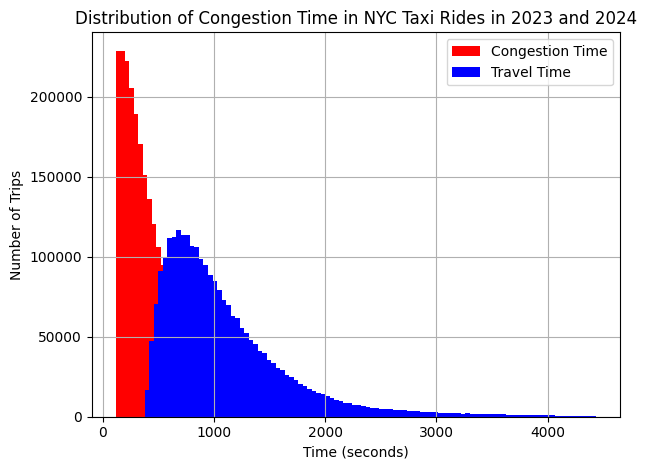

In [30]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
final_filtered_df_pd['congestion_time_seconds'].hist(ax=ax, bins = 100, color='red')
final_filtered_df_pd['travel_time_seconds'].hist(ax=ax, bins = 100, color='blue')
xlabel = "Time (seconds)"
ax.set_xlabel(xlabel)
ylabel = "Number of Trips"
ax.set_ylabel(ylabel)
title = "Distribution of Congestion Time in NYC Taxi Rides in 2023 and 2024"
ax.set_title(title)
ax.legend(['Congestion Time', 'Travel Time'])
plt.tight_layout()  
plt.show()

**Time Series Analysis**

In [31]:
dategroup_traindf = final_filtered_df.groupBy("date", "DOLocationID").agg(F.count("*").alias("trip_count"), F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.sum("congestion_time_seconds").alias("daily_congestion"), F.avg("travel_time_seconds").alias("average_travel_time_seconds"), F.sum("trip_distance").alias("total_trip_distance"),\
    F.avg("trip_distance").alias("average_trip_distance"),F.sum("fare_amount").alias("total_fare_amount"), F.sum("tip_amount").alias("total_tip_amount"),\
    F.sum("total_amount").alias("total_amount"), F.avg("total_amount").alias("avg_total_amount"))

In [32]:
dategroup_testdf = final_filtered_testdf.groupBy("date", "DOLocationID").agg(F.count("*").alias("trip_count"), F.expr("percentile_approx(congestion_time_seconds, 0.5)").alias("median_congestion_time_seconds"),\
    F.sum("congestion_time_seconds").alias("daily_congestion"), F.avg("travel_time_seconds").alias("average_travel_time_seconds"), F.sum("trip_distance").alias("total_trip_distance"),\
    F.avg("trip_distance").alias("average_trip_distance"),F.sum("fare_amount").alias("total_fare_amount"), F.sum("tip_amount").alias("total_tip_amount"),\
    F.sum("total_amount").alias("total_amount"), F.avg("total_amount").alias("avg_total_amount"))

In [33]:
id_summary_df = dategroup_traindf.groupBy("DOLocationID").agg(
    F.sum("daily_congestion").alias("total_congestion"),
    F.avg("daily_congestion").alias("avg_congestion"),
    F.expr("percentile_approx(daily_congestion, 0.5)").alias("median_congestion")
)

In [55]:
dategroup_testdf.show(10)

+----------+------------+----------+------------------------------+------------------+---------------------------+-------------------+---------------------+------------------+-----------------+------------------+------------------+
|      date|DOLocationID|trip_count|median_congestion_time_seconds|  daily_congestion|average_travel_time_seconds|total_trip_distance|average_trip_distance| total_fare_amount| total_tip_amount|      total_amount|  avg_total_amount|
+----------+------------+----------+------------------------------+------------------+---------------------------+-------------------+---------------------+------------------+-----------------+------------------+------------------+
|2007-12-05|         234|         1|            248.57142857142856|248.57142857142856|                     1020.0|                3.0|                  3.0|              17.0|              0.0|             22.75|             22.75|
|2024-12-31|          48|         1|            1770.5714285714287|1770.

In [35]:
# Sample 10% of the final filtered DataFrame for further analysis without stratification
dategroup_traindf_pd = dategroup_traindf.toPandas()
dategroup_testdf_pd = dategroup_testdf.toPandas()
id_summary_df_pd = id_summary_df.toPandas()

dategroup_traindf_pd.shape, id_summary_df_pd.shape

((112855, 12), (259, 4))

In [36]:
%pip install utilsforecast

Note: you may need to restart the kernel to use updated packages.


In [37]:
id_summary_df_pd.sort_values("median_congestion", ascending=False) # figure this out

,DOLocationID,total_congestion,avg_congestion,median_congestion
155,161,6.307734e+08,1.144779e+06,1.082784e+06
223,230,5.484325e+08,9.935372e+05,9.677616e+05
230,237,5.074057e+08,9.225558e+05,8.230240e+05
229,236,4.742354e+08,8.622462e+05,7.819507e+05
157,163,4.117542e+08,7.486440e+05,7.213293e+05
...,...,...,...,...
5,6,4.045429e+03,5.779184e+02,2.864286e+02
214,221,3.972429e+03,4.965536e+02,2.578571e+02
238,245,9.822857e+02,2.455714e+02,2.352857e+02
166,172,5.218714e+03,1.043743e+03,2.258571e+02


In [38]:
unique_ids = [161, 230, 237, 236, 170, 163]

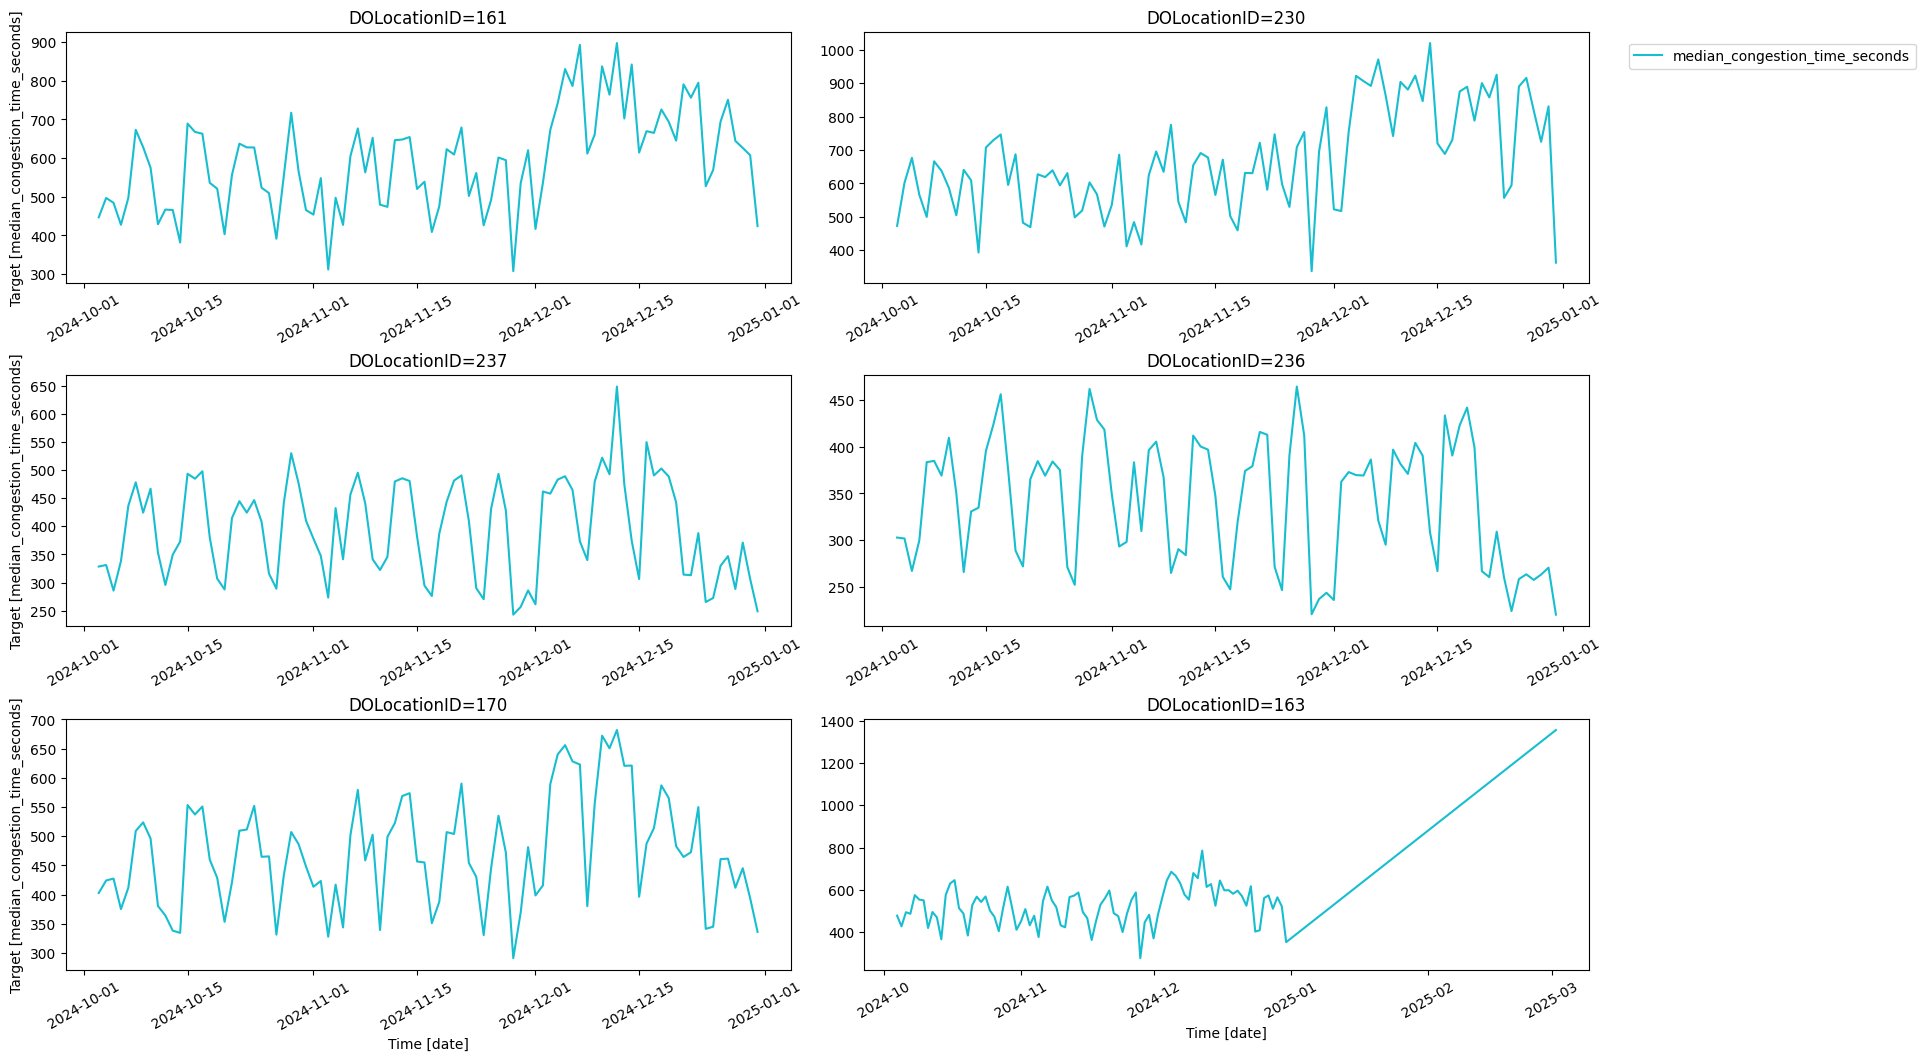

In [39]:
from utilsforecast.plotting import plot_series
dategroup_traindf_pd["date"] = pd.to_datetime(dategroup_traindf_pd["date"])
plot_series(
            df=dategroup_traindf_pd,
            ids =unique_ids, 
            time_col='date',
            target_col='median_congestion_time_seconds',
            id_col="DOLocationID",
            max_insample_length=90)

# max_insample_length = 500
# This is about 3-4 days of data for the LocationIDs in the unique_ids list 
# max_insample_length = 5000
# This would be about 30-40 days of data for the LocationIDs in the unique_ids list so around a month of data


**Training Linear Regression Model**

In [40]:
dategroup_traindf_pd.head(10)

,date,DOLocationID,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
0,2009-01-01,231,1,214.142857,214.142857,983.000000,2.99,2.990000,17.70,0.00,21.70,21.700000
1,2023-06-30,107,1,190.428571,190.428571,571.000000,1.48,1.480000,10.70,2.00,17.70,17.700000
2,2023-06-30,112,1,243.142857,243.142857,778.000000,2.08,2.080000,14.20,3.34,20.04,20.040000
3,2023-07-01,9,4,314.571429,1426.428571,1342.750000,15.34,3.835000,97.62,8.14,120.51,30.127500
4,2023-07-01,61,47,281.285714,15971.428571,1500.680851,212.18,4.514468,1197.93,152.92,1492.35,31.752128
5,2023-07-01,64,1,758.714286,758.714286,2893.000000,8.30,8.300000,44.30,10.50,63.05,63.050000
6,2023-07-01,66,56,284.571429,19978.142857,1190.446429,181.56,3.242143,1139.34,197.79,1558.63,27.832679
7,2023-07-01,96,1,131.571429,131.571429,939.000000,3.14,3.140000,17.00,3.70,22.20,22.200000
8,2023-07-01,98,1,386.142857,386.142857,2595.000000,8.59,8.590000,62.20,13.64,83.59,83.590000
9,2023-07-01,100,565,345.285714,227339.142857,952.014159,1207.69,2.137504,8904.43,1287.85,12620.48,22.337133


In [41]:
%pip install statsforecast

Note: you may need to restart the kernel to use updated packages.


In [42]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [43]:
# training only on the LocationIDs in the unique_ids list because the data is too large to train on all the LocationIDs
# this list contrains the LocationIDs with the highest proportion of congestion time in NYC taxi rides in 2023 and 2024
train_data_subset = dategroup_traindf_pd#[dategroup_traindf_pd["DOLocationID"].isin(unique_ids)]
test_data_subset = dategroup_testdf_pd#[dategroup_testdf_pd["DOLocationID"].isin(unique_ids)]
train_data_subset.shape, test_data_subset.shape

((112855, 12), (39838, 12))

In [ ]:
from sklearn.model_selection import train_test_split

# because lasso requires data entries for each ID to be greater than 1
counts = train_data_subset["DOLocationID"].value_counts()
valid_ids = counts[counts >= 2].index

train_data, validation_data = train_test_split(train_data_subset, train_size=0.8, random_state=23,stratify=train_data_subset["DOLocationID"].isin(valid_ids))
train_data_x = train_data.drop(columns=["median_congestion_time_seconds"])
train_data_y = train_data["median_congestion_time_seconds"]
validation_data_x = validation_data.drop(columns=["median_congestion_time_seconds"])
validation_data_y = validation_data["median_congestion_time_seconds"]
test_data_x = test_data_subset.drop(columns=["median_congestion_time_seconds"])
test_data_y = test_data_subset["median_congestion_time_seconds"]
train_data_full_x = train_data_subset.drop(columns=["median_congestion_time_seconds"])
train_data_full_y = train_data_subset["median_congestion_time_seconds"]

In [45]:
train_data

,date,DOLocationID,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
59964,2024-04-22,265,21,464.571429,1.266943e+04,1900.285714,105.92,5.043810,1111.48,146.58,1527.20,72.723810
5382,2024-04-15,87,203,378.857143,1.086534e+05,1433.566502,709.18,3.493498,4567.18,620.21,6149.77,30.294433
283,2023-07-15,168,9,243.571429,2.425143e+03,1048.888889,27.28,3.031111,160.70,8.00,190.20,21.133333
61770,2024-07-14,166,144,210.857143,3.773600e+04,1035.805556,433.30,3.009028,2599.35,301.29,3339.44,23.190556
52465,2024-10-29,142,2228,476.000000,1.296361e+06,1105.287702,4535.30,2.035592,38634.96,7413.19,57532.45,25.822464
...,...,...,...,...,...,...,...,...,...,...,...,...
109245,2023-08-21,28,7,277.285714,2.600286e+03,1249.428571,23.90,3.414286,146.70,4.00,173.20,24.742857
110235,2024-01-18,66,49,407.000000,2.226014e+04,1509.571429,201.09,4.103878,1234.23,230.35,1717.08,35.042449
28181,2024-06-15,188,40,444.142857,2.401443e+04,2008.025000,218.97,5.474250,1239.26,129.02,1478.28,36.957000
112281,2024-10-16,242,10,426.428571,6.635143e+03,1422.600000,29.52,2.952000,222.15,0.00,229.15,22.915000


In [46]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LassoCV
from sklearn.metrics import root_mean_squared_error, r2_score

In [47]:
# Identify categorical and numeric columns
cat_cols = ["date", "DOLocationID"] 
num_cols = [c for c in train_data.drop(columns=["median_congestion_time_seconds"]).columns if c not in cat_cols]

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

In [48]:
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LassoCV(cv=10, random_state=23))
])
lr_model.fit(train_data_x, train_data_y)

y_pred = lr_model.predict(validation_data_x)
print("R^2:", r2_score(validation_data_y, y_pred))
print("RMSE:", root_mean_squared_error(validation_data_y, y_pred))

R^2: 0.7847830397221197
RMSE: 125.48279334009374


In [49]:
# Baseline prediction = mean of training target
baseline_pred = np.full_like(validation_data_y, train_data_y.mean())

# Evaluate baseline
baseline_r2 = r2_score(validation_data_y, baseline_pred)
baseline_mse = root_mean_squared_error(validation_data_y, baseline_pred)

print("Baseline R^2:", baseline_r2)
print("Baseline RMSE:", baseline_mse)

Baseline R^2: -8.153101965580056e-05
Baseline RMSE: 270.49773617434806


In [50]:
lr_model.fit(train_data_full_x, train_data_full_y)

y_pred_full = lr_model.predict(test_data_x)
print("R^2:", r2_score(test_data_y, y_pred_full))
print("RMSE:", root_mean_squared_error(test_data_y, y_pred_full))

R^2: 0.7485248415845192
RMSE: 92.67666037738344


In [ ]:
# predicting for July 2025 using the June 2025
np.random.seed(23)
train_data_june24 = train_data[
    (train_data["date"] >= "2024-06-24") & (train_data["date"] <= "2024-06-30")
].copy()
train_data_june24
for lag in range (1, 8): # account for 7 days of lag for each day
    train_data_june24[f"lag{lag}"] = train_data_june24["median_congestion_time_seconds"].shift(lag)

train_data_june24 = train_data_june24.dropna().reset_index(drop=True)
train_data_june24


,date,DOLocationID,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount,lag1,lag2,lag3,lag4,lag5,lag6,lag7
0,2024-06-29,49,69,355.142857,29800.857143,1495.797101,285.48,4.137391,1720.78,276.90,2231.43,32.339565,768.857143,692.571429,562.285714,266.714286,658.857143,391.428571,573.428571
1,2024-06-25,53,6,457.714286,3184.285714,2245.000000,40.00,6.666667,227.30,14.60,281.15,46.858333,355.142857,768.857143,692.571429,562.285714,266.714286,658.857143,391.428571
2,2024-06-26,80,60,456.428571,35738.142857,1939.850000,313.65,5.227500,1906.82,263.77,2474.73,41.245500,457.714286,355.142857,768.857143,692.571429,562.285714,266.714286,658.857143
3,2024-06-27,85,12,1061.571429,13322.285714,2490.833333,64.43,5.369167,402.94,37.34,475.72,39.643333,456.428571,457.714286,355.142857,768.857143,692.571429,562.285714,266.714286
4,2024-06-28,243,37,428.142857,20309.571429,2265.648649,247.02,6.676216,1395.54,87.69,1649.49,44.580811,1061.571429,456.428571,457.714286,355.142857,768.857143,692.571429,562.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1208,2024-06-24,249,903,334.285714,352442.428571,979.480620,2069.00,2.291251,14776.52,2688.44,22147.28,24.526334,309.142857,494.857143,379.571429,343.142857,385.714286,335.428571,310.571429
1209,2024-06-29,159,4,280.142857,1240.714286,1032.750000,11.24,2.810000,76.25,2.44,84.19,21.047500,334.285714,309.142857,494.857143,379.571429,343.142857,385.714286,335.428571
1210,2024-06-26,26,15,619.714286,10628.428571,2824.333333,123.42,8.228000,661.82,11.97,746.55,49.770000,280.142857,334.285714,309.142857,494.857143,379.571429,343.142857,385.714286
1211,2024-06-28,248,1,1219.857143,1219.857143,2557.000000,5.20,5.200000,24.50,0.00,25.00,25.000000,619.714286,280.142857,334.285714,309.142857,494.857143,379.571429,343.142857


In [51]:
test_data_y.sort_values(ascending=False)

779      3409.714286
24990    3211.714286
21429    3194.571429
36152    3110.142857
36435    3089.428571
            ...     
5200      120.285714
34200     120.285714
38691     120.285714
39138     120.142857
16659     120.142857
Name: median_congestion_time_seconds, Length: 39838, dtype: float64

In [52]:
from utilsforecast.evaluation import evaluate
from statsforecast.models import AutoARIMA
from utilsforecast.plotting import plot_series
from statsforecast import StatsForecast
from utilsforecast.losses import *

/opt/anaconda3/envs/pyspark-env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
train_data.head()

,date,DOLocationID,trip_count,median_congestion_time_seconds,daily_congestion,average_travel_time_seconds,total_trip_distance,average_trip_distance,total_fare_amount,total_tip_amount,total_amount,avg_total_amount
59964,2024-04-22,265,21,464.571429,1.266943e+04,1900.285714,105.92,5.043810,1111.48,146.58,1527.20,72.723810
5382,2024-04-15,87,203,378.857143,1.086534e+05,1433.566502,709.18,3.493498,4567.18,620.21,6149.77,30.294433
283,2023-07-15,168,9,243.571429,2.425143e+03,1048.888889,27.28,3.031111,160.70,8.00,190.20,21.133333
61770,2024-07-14,166,144,210.857143,3.773600e+04,1035.805556,433.30,3.009028,2599.35,301.29,3339.44,23.190556
52465,2024-10-29,142,2228,476.000000,1.296361e+06,1105.287702,4535.30,2.035592,38634.96,7413.19,57532.45,25.822464


In [54]:
from statsforecast.models import AutoARIMA
# There is roughly a daily cycle in the congestion time in NYC taxi rides, so we can use a seasonal ARIMA model
# The season_length is set to 5000/30 because there are about 5000 data points in a month and we want to capture the monthly seasonality
models = [
    AutoARIMA(seasonal=False, alias="AutoARIMA"),
    
    AutoARIMA(season_length = 5000//30, alias="SARIMA"),
]

sf = StatsForecast(
    models=models,
    freq="D",
)
sf.fit(
    df=train_data,
    time_col="pickup_datetime",
    target_col="congestion_time_seconds",
    id_col="DOLocationID")

# predicting for 5 months ahead
# 5000 data points per month, so 5000*5 = 25000 data points for 5 months ahead
# This is to predict the congestion time for the next 5 months  
arima_preds = sf.predict(horizon=30*5)
arima_preds = arima_preds.rename(columns={"DOLocationID": "LocationID", "pickup_datetime": "pickup_datetime"})

# Merging the predictions with the test data
# to evaluate the model performance
arima_eval_df = pd.merge(
    test_data_subset,
    arima_preds,
    on=["DOLocationID", "pickup_datetime"],
    how="left" 
)

arima_eval_df = arima_eval_df.rename(columns={"congestion_time_seconds": "actual", "AutoARIMA": "predicted"})

arima_eval = evaluate(
    df=arima_eval_df,
    metrics=[rmse],
)

arima_eval

KeyError: 'pickup_datetime'

In [ ]:
train_data['pickup_datetime'].dtype


dtype('<M8[ns]')

In [ ]:
print(train_data['congestion_time_seconds'].apply(type).value_counts())


congestion_time_seconds
<class 'float'>    396004
Name: count, dtype: int64


In [ ]:
train_data['congestion_time_seconds'] = pd.to_numeric(
    train_data['congestion_time_seconds'], errors='coerce'
)

# check if any values are NaN or None
print(train_data['congestion_time_seconds'].apply(type).value_counts())

congestion_time_seconds
<class 'float'>    396004
Name: count, dtype: int64
